# 04 — Walk-forward GBM (Case B)

Expanding-window global `HistGradientBoostingRegressor`:

- train on `date < t`, score `date == t` for each Tuesday `t ≥ 2025-01-07`
- features via `LaneWeekFeatureBuilder` (lagged RPM + `availability_lag_1`; no same-week availability / rate bands)
- **residual target:** learn `delta = rpm − rpm_lag_1`, then `pred = rpm_lag_1 + deltâ`
- baseline = `rpm_lag_1`

Prefer the reproducible script for full runs:

```bash
python scripts/train_walkforward_gbm.py
```

This notebook loads saved metrics (or re-runs) and plots weekly MAE plus actual vs predicted RPM.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from freight_rates.ingestion import load_raw_snapshot
from freight_rates.preprocessing import build_lane_week_panel
from freight_rates.splits import filter_model_window
from freight_rates.walkforward import run_walkforward_gbm, save_walkforward_outputs

ROOT = Path("..").resolve()
OUT = ROOT / "models" / "walkforward_gbm"
PRED_PATH = OUT / "walkforward_gbm_predictions.parquet"
WEEK_PATH = OUT / "walkforward_gbm_metrics_by_week.csv"
HIST_PATH = OUT / "walkforward_gbm_metrics_by_history.csv"
OVERALL_PATH = OUT / "walkforward_gbm_metrics_overall.csv"

In [15]:
need_rerun = True
if PRED_PATH.exists() and WEEK_PATH.exists():
    preds = pd.read_parquet(PRED_PATH)
    # Re-run if artifacts predate residual targeting (missing delta_hat).
    need_rerun = "delta_hat" not in preds.columns

if not need_rerun:
    by_week = pd.read_csv(WEEK_PATH, parse_dates=["date"])
    by_history = pd.read_csv(HIST_PATH)
    overall = pd.read_csv(OVERALL_PATH)
    print("Loaded saved walk-forward outputs from", OUT)
else:
    print("Running walk-forward with residual target (may take a few minutes)...")
    panel = filter_model_window(build_lane_week_panel(load_raw_snapshot(raw_dir=ROOT / "data" / "raw")))
    result = run_walkforward_gbm(panel, residual_target=True, verbose=True)
    save_walkforward_outputs(result, OUT)
    preds, by_week, by_history, overall = (
        result.predictions,
        result.by_week,
        result.by_history,
        result.overall,
    )

display(overall)
display(by_history)

Loaded saved walk-forward outputs from /Users/angel/Documents/freight_rate/models/walkforward_gbm


,n,mae,medae,mape,mae_baseline,medae_baseline,mae_lift
0,5689,0.166032,0.057163,4.633728,0.139284,0.016667,-0.026748


,history_bucket,n,mae,medae,mape,mae_baseline,medae_baseline,mae_lift
0,0-4,246,0.390161,0.187758,11.670180,0.406777,0.188696,0.016616
1,5-19,593,0.223575,0.094281,6.147318,0.186153,0.052632,-0.037422
2,20-99,4613,0.148686,0.047383,4.119964,0.120386,0.000000,-0.028299
3,100+,237,0.127034,0.084371,3.542886,0.112180,0.062016,-0.014854


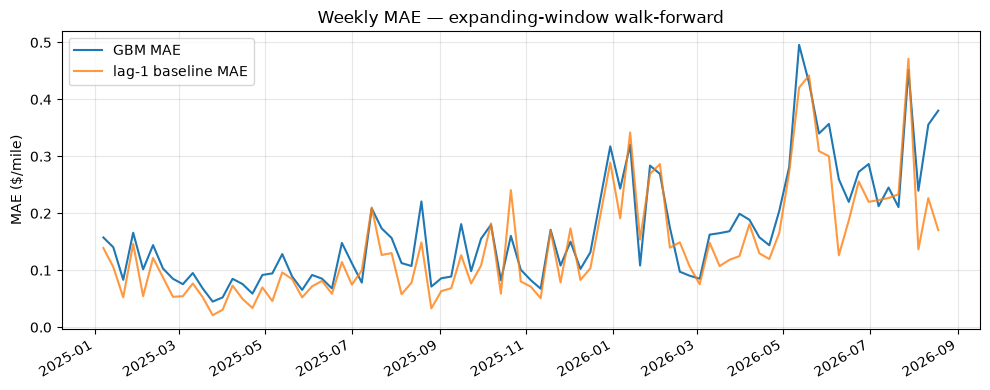

scored rows: 5,689


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_week["date"], by_week["mae"], label="GBM MAE")
if "mae_baseline" in by_week.columns:
    ax.plot(by_week["date"], by_week["mae_baseline"], label="lag-1 baseline MAE", alpha=0.8)
ax.set_title("Weekly MAE — expanding-window walk-forward (residual GBM)")
ax.set_ylabel("MAE ($/mile)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"scored rows: {len(preds):,}")

In [ ]:
# Actual vs GBM predicted RPM (weekly mean across lanes), plus scatter.
weekly_levels = (
    preds.groupby("date", as_index=False)
    .agg(
        rpm_true=("y_true", "mean"),
        rpm_gbm=("y_pred", "mean"),
        rpm_lag1=("y_pred_baseline", "mean"),
        n=("y_true", "size"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(weekly_levels["date"], weekly_levels["rpm_true"], label="Actual RPM (weekly mean)", lw=1.8)
axes[0].plot(weekly_levels["date"], weekly_levels["rpm_gbm"], label="GBM pred (weekly mean)", lw=1.4, alpha=0.9)
axes[0].set_title("Actual vs GBM — weekly mean RPM")
axes[0].set_ylabel("RPM ($/mile)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
fig.autofmt_xdate()

# Subsample for readability if many points
scatter = preds.sample(n=min(2500, len(preds)), random_state=42)
axes[1].scatter(scatter["y_true"], scatter["y_pred"], s=8, alpha=0.25, color="steelblue")
lims = [
    min(scatter["y_true"].min(), scatter["y_pred"].min()),
    max(scatter["y_true"].max(), scatter["y_pred"].max()),
]
axes[1].plot(lims, lims, color="black", lw=1, ls="--", label="y = x")
axes[1].set_xlabel("Actual RPM ($/mile)")
axes[1].set_ylabel("GBM predicted RPM ($/mile)")
axes[1].set_title("Actual vs GBM — lane-week scatter")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

weekly_levels.head()
